# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [2]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

### Double check some datatypes, and for nulls and duplicates:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [7]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [8]:
df.Segment.unique()

<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [9]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [10]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [11]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [70]:
query1 = """ SELECT 
    c.customer_category as Customer_Category,
    ROUND(SUM(od.sales), 2) AS Total_Sales,
    ROUND(SUM(od.profit), 2) AS Total_Profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,Customer_Category,Total_Sales,Total_Profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [69]:
query2 = """ select
    c.customer_name as Customer_Name,
    ROUND(SUM(od.sales), 2) as Total_Sales
 from customers c
 join orders o on c.customer_id = o.customer_id
 join order_details od on o.order_id = od.order_id
 group by c.customer_name
 order by total_sales DESC
 limit 10;
 """
result2 = pd.read_sql(query2, conn)
result2

,Customer_Name,Total_Sales
0,Ken Lonsdale,155927.52
1,Sanjit Engle,134303.82
2,Clay Ludtke,130566.55
3,Adrian Barton,130262.14
4,Sanjit Chand,127281.01
5,Sean Miller,125215.25
6,Edward Hooks,123730.56
7,Greg Tran,118201.20
8,Seth Vernon,114709.50
9,John Lee,107799.15


### Which product categories and subcategories are the most profitable overall?

In [98]:
query3 = """ select 
    p.category as Category,
    p.subcategory as Subcategory,
    ROUND(SUM(od.profit), 2) as Total_Profit,
    ROUND(SUM(od.profit) / SUM(od.sales) * 100, 2) as Profit_Margin
from products p
join order_details od on p.product_id = od.product_id
group by p.category, p.subcategory
order by total_profit DESC;
"""
result3 = pd.read_sql(query3, conn)
result3

,Category,Subcategory,Total_Profit,Profit_Margin
0,Technology,Copiers,55617.82,37.20
1,Technology,Accessories,48359.05,25.06
2,Technology,Phones,46936.19,13.16
3,Office Supplies,Paper,36994.53,43.44
4,Office Supplies,Binders,30373.20,14.38
5,Furniture,Chairs,26707.65,8.07
6,Office Supplies,Storage,21408.70,9.52
7,Office Supplies,Appliances,18514.49,16.90
8,Furniture,Furnishings,14569.59,14.77
9,Office Supplies,Envelopes,6964.18,42.27


### What is the average discount given per category?

In [67]:
query4 = """  select 
    p.category as Category,
    ROUND(AVG(od.discount), 2) as Avg_Discount
from products p
join order_details od on p.product_id = od.product_id
group by p.category
order by avg_discount DESC;
"""
result4 = pd.read_sql(query4, conn)
result4

,Category,Avg_Discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


### Which states or regions contribute the most to total sales?

In [95]:
query5 = """  select 
    c.state as State,
    c.region as Region,
    ROUND(SUM(od.sales), 2) as Total_Sales
from customers c
join orders o on c.customer_id = o.customer_id
join order_details od on o.order_id = od.order_id
group by c.state, c.region
order by c.region, total_sales DESC, c.state;
"""
result5 = pd.read_sql(query5, conn)
result5

,State,Region,Total_Sales
0,Texas,Central,1547925.76
1,Illinois,Central,843352.76
2,Michigan,Central,432428.02
3,Indiana,Central,264912.84
4,Wisconsin,Central,186075.75
5,Minnesota,Central,168387.68
6,Oklahoma,Central,101223.06
7,Missouri,Central,83206.77
8,Nebraska,Central,70650.40
9,Iowa,Central,59973.77


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [64]:
query6 = """ select 
    order_id as Order_ID,
    ship_date as Ship_Date,
    order_date as Order_Date,
    CAST((julianday(ship_date) - julianday(order_date)) as INTEGER) as Days_to_Ship
from orders
where julianday(ship_date) - julianday(order_date) > 3
order by days_to_ship DESC;
"""
result6 = pd.read_sql(query6, conn)
result6

,Order_ID,Ship_Date,Order_Date,Days_to_Ship
0,US-2012-108966,2012-10-18 00:00:00,2012-10-11 00:00:00,7
1,CA-2011-105893,2011-11-18 00:00:00,2011-11-11 00:00:00,7
2,CA-2014-155558,2014-11-03 00:00:00,2014-10-27 00:00:00,7
3,CA-2013-128867,2013-11-11 00:00:00,2013-11-04 00:00:00,7
4,US-2014-107272,2014-11-13 00:00:00,2014-11-06 00:00:00,7
...,...,...,...,...
3386,CA-2011-111157,2011-03-06 00:00:00,2011-03-02 00:00:00,4
3387,CA-2012-103772,2012-07-02 00:00:00,2012-06-28 00:00:00,4
3388,US-2013-103674,2013-12-11 00:00:00,2013-12-07 00:00:00,4
3389,CA-2013-125794,2013-10-04 00:00:00,2013-09-30 00:00:00,4


### Which month or year had the highest total sales?
This question, as written, is very confusing. What are we looking for, the highest month's sales and the highest years sales or are we looking to 
compare the month sales against the year sales? I guess my question is, are we looking for one total or two? I seems clear, but why would we compare
monthly sales against yearly sales? I found the 'UNION ALL' function and was able to get an output that lists all the years and then all the months. There are
couple of the earlier queries that were nearly as confusing, but I did not spend as much time on them as I did this one. Were these all written by AI?

In [71]:
query7 = """ select 
    'Month' as Year_Month,
    strftime('%Y-%m', o.order_date) as Time_Period,
    ROUND(SUM(od.sales), 2) as Total_Sales
from orders o
join order_details od on o.order_id = od.order_id
group by Time_Period

union all

select 
    'Year' as Year_Month,
    strftime('%Y', o.order_date) as Time_Period,
    ROUND(SUM(od.sales), 2) as Total_Sales
from orders o
join order_details od on o.order_id = od.order_id
group by Time_Period
order by Total_Sales DESC, Year_Month, Time_Period;
"""
result7 = pd.read_sql(query7, conn)
result7

,Year_Month,Time_Period,Total_Sales
0,Year,2014,733947.02
1,Year,2013,608473.83
2,Year,2011,484247.50
3,Year,2012,470532.51
4,Month,2014-11,112326.47
5,Month,2013-12,97237.42
6,Month,2014-09,90488.72
7,Month,2014-12,90474.60
8,Month,2013-11,82192.32
9,Month,2011-09,81777.35


### What are the most frequently ordered products?

In [72]:
query8 = """ select 
    p.product_id as Product_ID,
    p.product_name as Product_Name,
    COUNT(*) as Order_Count
from products p
join order_details od on p.product_id = od.product_id
group by p.product_id, p.product_name
order by Order_Count DESC
limit 10;
"""
result8 = pd.read_sql(query8, conn)
result8

,Product_ID,Product_Name,Order_Count
0,OFF-PA-10001970,Xerox 1881,19
1,OFF-PA-10001970,Xerox 1908,19
2,TEC-AC-10003832,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,18
3,TEC-AC-10003832,Logitech P710e Mobile Speakerphone,18
4,FUR-FU-10004270,"Eldon Image Series Desk Accessories, Burgundy",16
5,FUR-FU-10004270,"Executive Impressions 13"" Clairmont Wall Clock",16
6,FUR-CH-10001146,"Global Task Chair, Black",15
7,FUR-CH-10001146,"Global Value Mid-Back Manager's Chair, Gray",15
8,FUR-CH-10002647,"Situations Contoured Folding Chairs, 4/Set",15
9,TEC-AC-10002049,Logitech G19 Programmable Gaming Keyboard,15


### Which customers placed more than 5 orders total?

In [76]:
query9 = """ select
    c.customer_id as Customer_ID,
    c.customer_name as Customer_Name,
    COUNT(o.order_id) as Total_Orders
from customers c
join orders o on c.customer_id = o.customer_id
group by c.customer_id, c.customer_name
having Total_Orders > 5
order by Total_Orders DESC;
"""
result9 = pd.read_sql(query9, conn)
result9

,Customer_ID,Customer_Name,Total_Orders
0,EP-13915,Emily Phan,289
1,EA-14035,Erin Ashbrook,169
2,JE-15745,Joel Eaton,169
3,SH-19975,Sally Hughsby,169
4,ZC-21910,Zuschuss Carroll,169
...,...,...,...
742,SS-20515,Shirley Schmidt,9
743,SW-20350,Sean Wendt,9
744,TM-21490,Tony Molinari,9
745,TT-21265,Tim Taslimi,9


### What’s the profit margin (profit ÷ sales) by category or segment?

In [88]:
query10 = """ select 
    p.category as Category_Segment,
    ROUND(SUM(od.sales), 2) as Total_Sales,
    ROUND(SUM(od.profit), 2) as Total_Profit,
    ROUND(SUM(od.profit) / SUM(od.sales) * 100, 2) as Profit_Margin
from products p
join order_details od ON p.product_id = od.product_id
group by p.category

union all 

select 
    c.customer_category as Category_Segment,
    ROUND(SUM(od.sales), 2) as Total_Sales,
    ROUND(SUM(od.profit), 2) as Total_Profit,
    ROUND(SUM(od.profit) / SUM(od.sales) * 100, 2) as Profit_Margin
from customers c
join orders o on c.customer_id = o.customer_id
join order_details od on o.order_id = od.order_id
group by c.customer_category
order by p.category, c.customer_category, Profit_Margin DESC;
"""
result10 = pd.read_sql(query10, conn)
result10

,Category_Segment,Total_Sales,Total_Profit,Profit_Margin
0,Consumer,8380282.43,973085.86,11.61
1,Corporate,5044899.83,660287.69,13.09
2,Furniture,764284.65,20098.89,2.63
3,Home Office,2964459.36,434344.01,14.65
4,Office Supplies,736748.59,126113.35,17.12
5,Technology,893633.28,153415.70,17.17


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

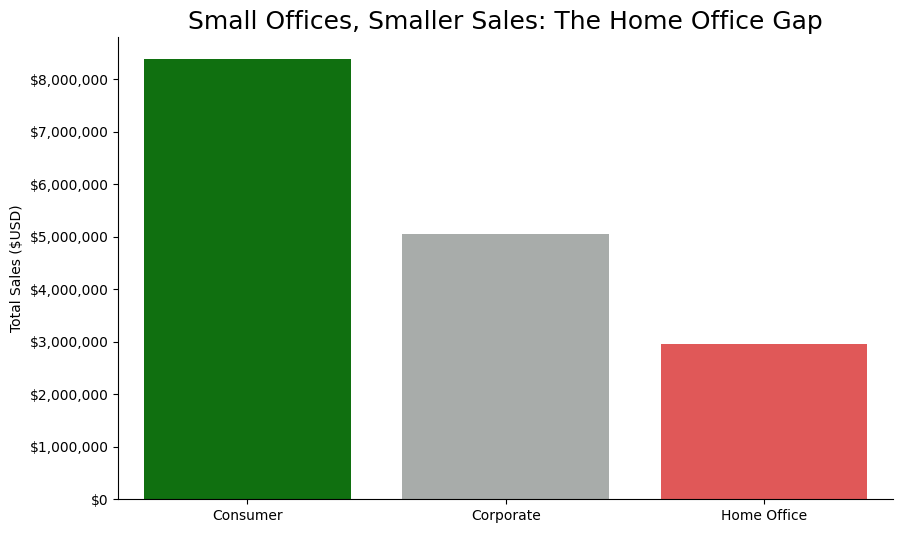

In [134]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["green", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='Customer_Category', y='Total_Sales', palette=colors, hue='Customer_Category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


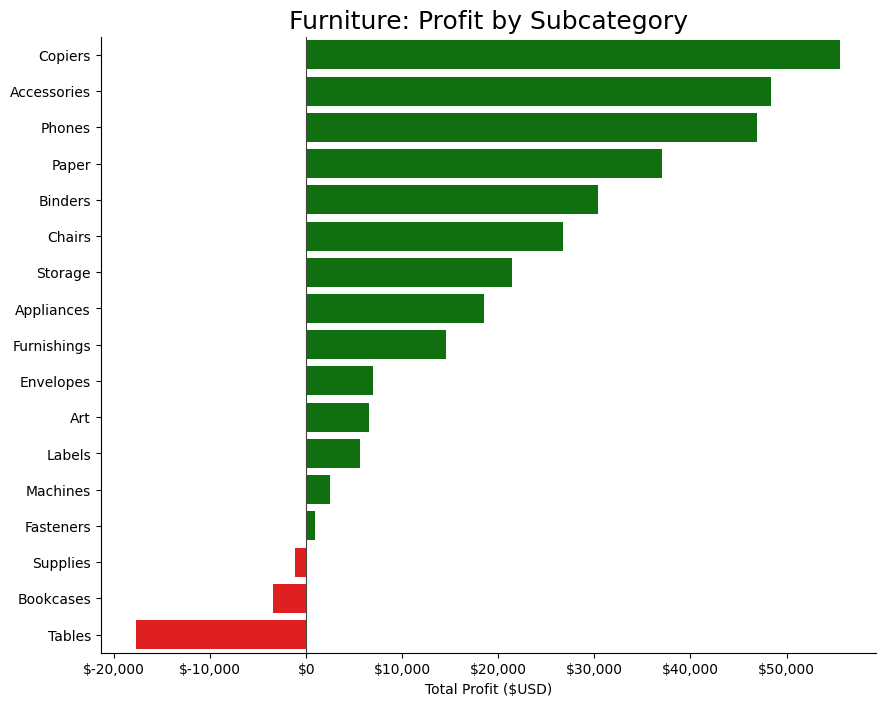

In [ ]:
# visualization one code here - result3
plt.figure(figsize=(10,8))
colors = ['red' if v < 0 else 'green' for v in result3['Total_Profit']]
sns.barplot(result3, x='Total_Profit', y='Subcategory', palette=colors, hue='Subcategory', legend=False)
plt.title('Furniture: Profit by Subcategory', fontsize=18)
plt.xlabel('Total Profit ($USD)')
plt.ylabel(None)

ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axvline(0, color='#444441', linewidth=0.8)

sns.despine()
plt.show()

C:\Users\iceka\AppData\Local\Temp\ipykernel_47132\551037881.py:4: UserWarning: 
The palette list has fewer values (3) than needed (49) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(result5, x='State', y='Total_Sales', palette=colors, hue='State', legend=False)


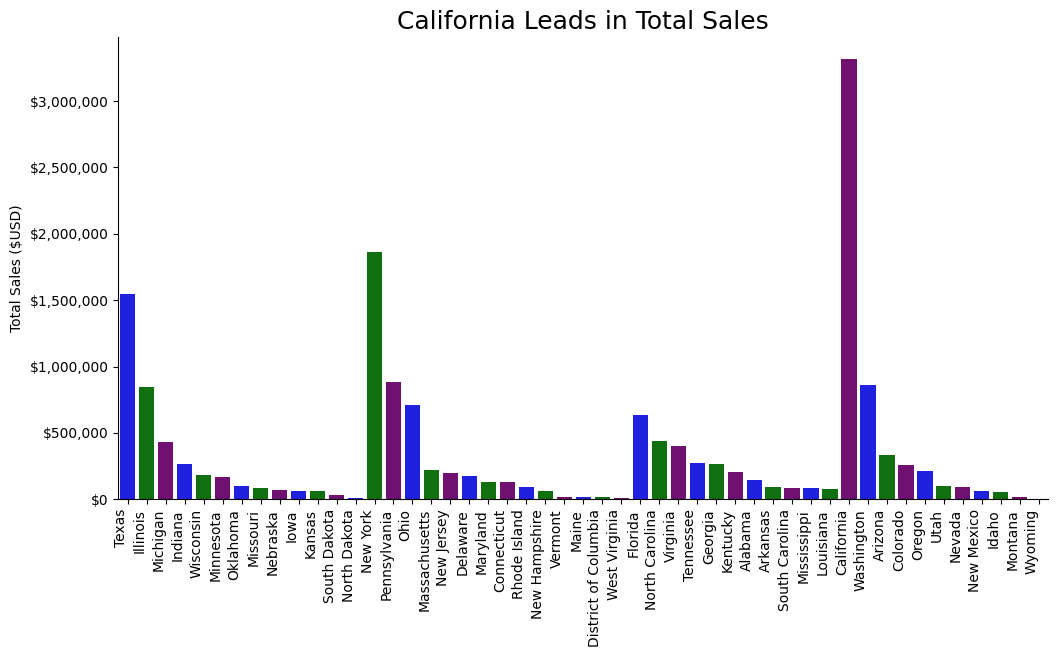

In [ ]:
# visualization two code here - result5
plt.figure(figsize=(12,6))
colors = ["blue", "green", "purple" ]
sns.barplot(result5, x='State', y='Total_Sales', palette=colors, hue='State', legend=False)
plt.title('California Leads in Total Sales', fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')
plt.xticks(rotation=90, ha='right')

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.despine()
plt.show()

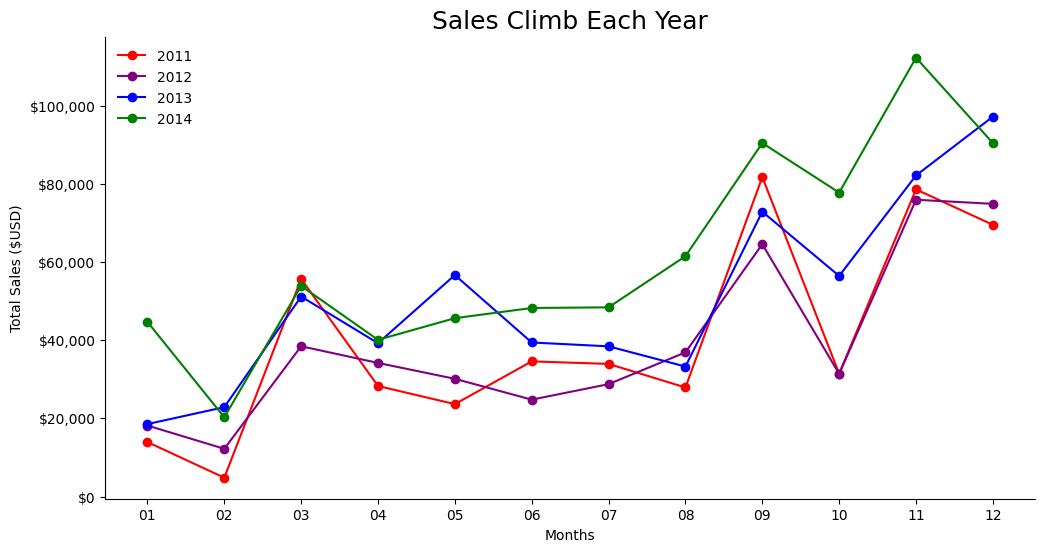

In [156]:
# visualization three code here result7
months_df = result7[result7['Year_Month'] == 'Month'].copy()
months_df['year'] = months_df['Time_Period'].str[:4]
months_df['month'] = months_df['Time_Period'].str[5:7]
months_df = months_df.sort_values('Time_Period')

plt.figure(figsize=(12,6))

years = sorted(months_df['year'].unique())
colors = ['red','purple', 'blue', 'green'] 

for year, color in zip(years, colors):
    year_data = months_df[months_df['year'] == year].sort_values('month')
    plt.plot(year_data['month'], year_data['Total_Sales'], color=color, marker='o', label=year)

plt.title('Sales Climb Each Year', fontsize=18)
plt.xlabel('Months')
plt.ylabel('Total Sales ($USD)')
plt.legend(frameon=False)

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.despine()
plt.show()

C:\Users\iceka\AppData\Local\Temp\ipykernel_47132\1419892928.py:4: UserWarning: 
The palette list has fewer values (3) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(result10, x='Category_Segment', y='Profit_Margin', palette=colors, hue='Category_Segment', legend=False)


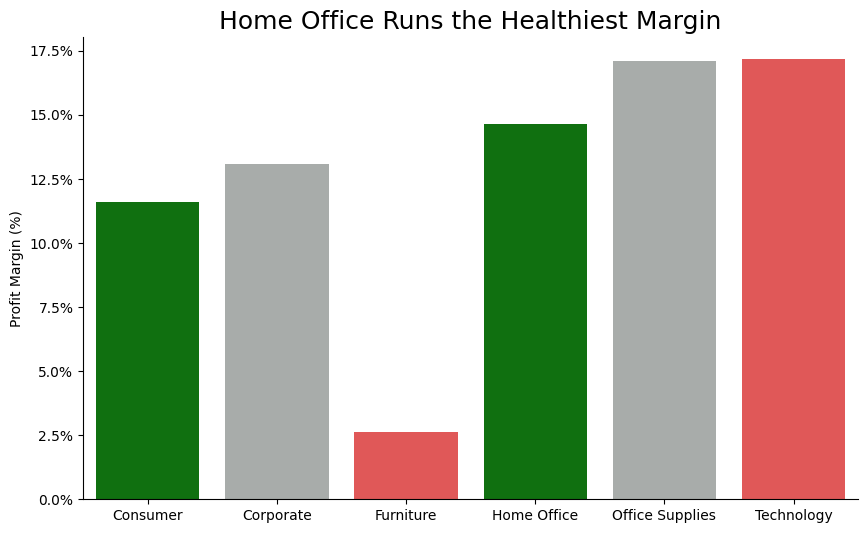

In [135]:
# visualization four code here result10
plt.figure(figsize=(10,6))
colors = ["green", "#a7adaa", "#f74141" ]
sns.barplot(result10, x='Category_Segment', y='Profit_Margin', palette=colors, hue='Category_Segment', legend=False)
plt.title('Home Office Runs the Healthiest Margin', fontsize=18)
plt.xlabel(None)
plt.ylabel('Profit Margin (%)')

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

sns.despine()
plt.show()